# Phase 2: Feature Map Visualization
In this notebook, we pass an image through the VGG19 Neural Network and visualize the mathematical 'feature maps' it generates.

In [1]:
import sys
import os
import torch
import matplotlib.pyplot as plt

# Add src to path
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

from data.image_loader import load_image
from models.vgg_feature_extractor import VGGFeatureExtractor

In [2]:
# 1. Load the Content Image
content_path = '../data/content_images/mcgregor.jpg'
image = load_image(content_path, max_size=400)

# 2. Initialize our Feature Extractor model
model = VGGFeatureExtractor()

# If you have a GPU, move the model and image to CUDA for speed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = model.to(device)
image = image.to(device)

# 3. Extract Features!
features = model(image)

# See what layers we extracted
print("Extracted Feature Maps:")
for layer_name, feature_map in features.items():
    print(f"{layer_name}: {feature_map.shape}")

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\suriy/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth


100.0%


Using device: cpu
Extracted Feature Maps:
conv1_1: torch.Size([1, 64, 500, 400])
conv2_1: torch.Size([1, 128, 250, 200])
conv3_1: torch.Size([1, 256, 125, 100])
conv4_1: torch.Size([1, 512, 62, 50])
conv4_2: torch.Size([1, 512, 62, 50])
conv5_1: torch.Size([1, 512, 31, 25])


Notice the shapes above:
- In `conv1_1` (early layer), the image is 400x320, but the Channels went from 3 (RGB) to 64! The network is looking at 64 different texture filters.
- In `conv5_1` (deep layer), the image shrunk to 25x20 due to Pooling, but the Channels exploded to 512! It is now tracking 512 complex concepts.

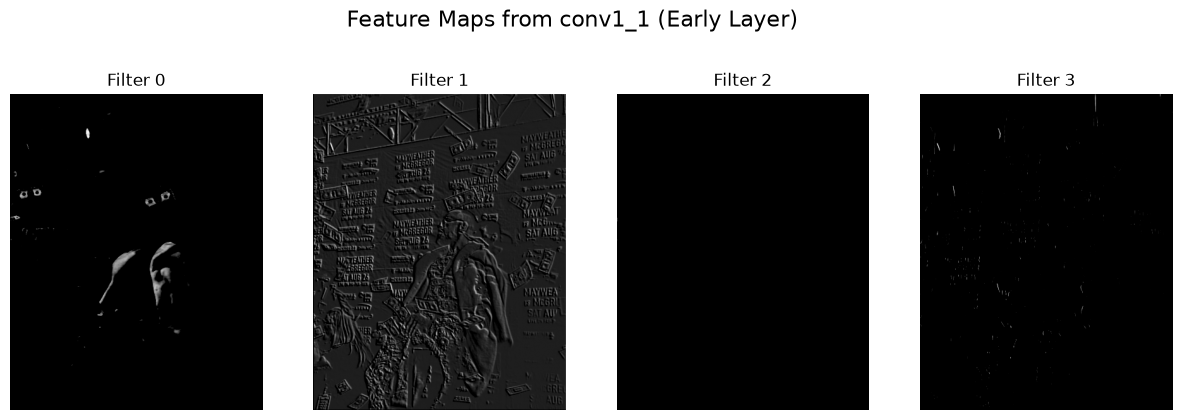

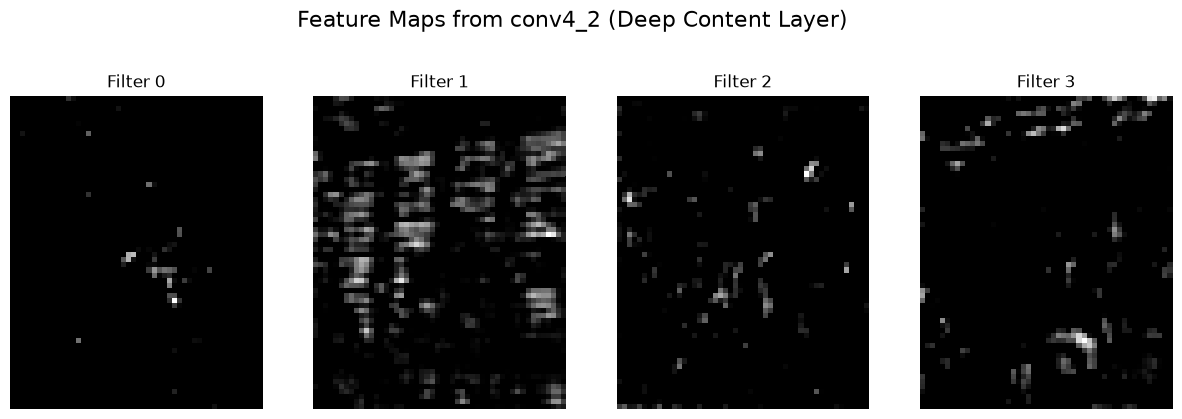

In [3]:
def plot_feature_map(feature_tensor, layer_name):
    """
    Takes a 3D feature tensor [Channels, Height, Width] from a specific layer
    and plots the first 4 channels so we can see what the AI is looking at.
    """
    # Remove batch dimension
    features_tensor = feature_tensor.squeeze(0).cpu().detach()
    
    fig, axes = plt.subplots(1, 4, figsize=(15, 5))
    fig.suptitle(f"Feature Maps from {layer_name}", fontsize=16)
    
    # Plot the first 4 filters out of the 64 or 512 available
    for i in range(4):
        # Extract one single 2D channel
        channel = features_tensor[i]
        axes[i].imshow(channel.numpy(), cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f"Filter {i}")
        
    plt.show()

# Visualize an EARLY layer (captures low-level textures, edges, colors)
plot_feature_map(features['conv1_1'], 'conv1_1 (Early Layer)')

# Visualize a DEEP layer (captures high-level structure, shapes, content)
plot_feature_map(features['conv4_2'], 'conv4_2 (Deep Content Layer)')